## Notebook to learn to play with tif images

In [1]:
import os
import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchinfo
import pprint

from utils import utils
from data_builder import build_tags
from data_builder import data_loader
from model_builder import build_model
import trainer.metrics as metrics_module

from trainer.trainer import Trainer

In [ ]:
# TODO: modify loss function
# TODO: add subsampling
# TODO: add documentation and correct doc

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"pytorch version = {torch.__version__}")

python version = 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:36:57) [Clang 15.0.7 ]
numpy version = 1.26.4
pytorch version = 2.1.2.post3


In [3]:
# GET config
EXP_NAME = "exp_001"
config = utils.get_config(EXP_NAME)
config["mode"] = "training"
# display(config)

# SET RANDOM SEEDS
torch.manual_seed(config["seed"])
torch.cuda.manual_seed(config["seed"])
np.random.seed(config["seed"])
random.seed(config["seed"])
torch.backends.cudnn.deterministic = True

# SET DIRECTORIES
directory_paths = utils.get_directories()
FIGURE_DIRECTORY = directory_paths["figures_dir"]
MODEL_DIRECTORY = directory_paths["save_model_dir"]

In [4]:
# LOAD THE DATA
tags_train, tags_val = build_tags.get_tags(config)

ds_train = data_loader.CustomData(config, tags_train)
train_loader = torch.utils.data.DataLoader(
    ds_train,
    batch_size=None,
    batch_sampler=None,
    shuffle=True,
    drop_last=False,
)

ds_val = data_loader.CustomData(config, tags_val)
val_loader = torch.utils.data.DataLoader(
    ds_val,
    batch_size=None,
    batch_sampler=None,
    shuffle=False,
    drop_last=False,
)

x, y = train_loader.dataset[0]
print(f"{x.shape = }")
print(f"{y.shape = }")

30.0 40.0 70.0 80.0


landsat_40lat_70lon_2020
...frac_land.round(3) = 1.0, # samples = 24800

total training samples = 23712, total validation samples = 1088

x.shape = torch.Size([32, 6, 110, 110])
y.shape = torch.Size([32, 1])


In [5]:
# BUILD THE MODEL
model = build_model.TorchModel(config)

# print the model summary
input_shape = (
    64,
    len(config["channels"]),
    config["scene_width_landsat"],
    config["scene_width_landsat"],
)
# torchinfo.summary(
#     model,
#     input_shape,
#     verbose=1,
#     col_names=("input_size", "output_size", "num_params"),
# )

In [6]:
# Setup the optimizer, loss function, and metrics
optimizer = getattr(torch.optim, config["optimizer"]["type"])(
    model.parameters(), **config["optimizer"]["args"]
)
criterion = torch.nn.MSELoss()
metric_funcs = [getattr(metrics_module, met) for met in config["metrics"]]

# BUILD THE TRAINER
device = utils.prepare_device(config["device"])
trainer = Trainer(
    model,
    criterion,
    metric_funcs,
    optimizer,
    max_epochs=config["trainer"]["max_epochs"],
    data_loader=train_loader,
    validation_data_loader=val_loader,
    device=device,
    config=config,
)

In [7]:
# FIT THE MODEL

# Train the Model
model.to(device)
trainer.fit()
model.eval()

# Save the Pytorch Model
model_name = utils.get_model_name(config["exp_name"], config["seed"])
utils.save_torch_model(model, MODEL_DIRECTORY + model_name + ".pt")


Epoch   0/ 5
  19.6s - train_loss: 152.44097 - val_loss: 120.40718
Epoch   1/ 5
  19.5s - train_loss: 119.61959 - val_loss: 94.16685
Epoch   2/ 5
  19.6s - train_loss: 131.84318 - val_loss: 125.48243
Epoch   3/ 5
  19.8s - train_loss: 102.43158 - val_loss: 113.74570
Epoch   4/ 5
  19.6s - train_loss: 102.38600 - val_loss: 93.29077
Epoch   5/ 5
  19.5s - train_loss: 109.66937 - val_loss: 99.18943


dict_keys(['epoch', 'loss', 'val_loss', 'custom_mae', 'val_custom_mae'])


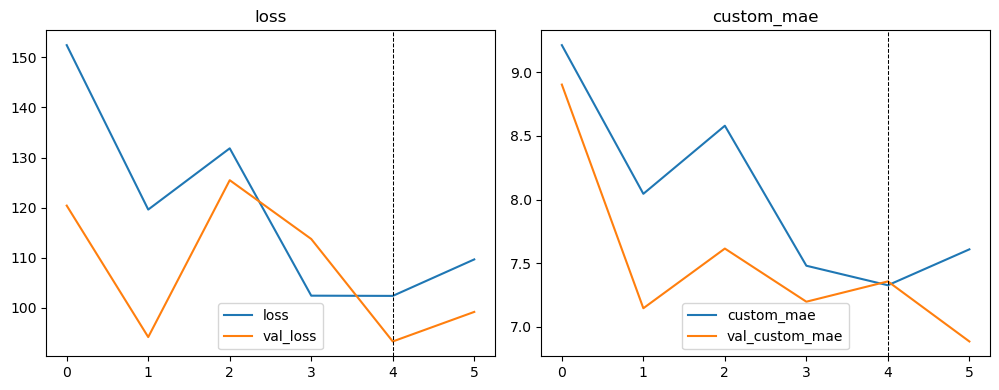

In [8]:
print(trainer.log.history.keys())

plt.figure(figsize=(20, 4))
for i, m in enumerate(("loss", *config["metrics"])):
    plt.subplot(1, 4, i + 1)
    plt.plot(trainer.log.history["epoch"], trainer.log.history[m], label=m)
    plt.plot(
        trainer.log.history["epoch"], trainer.log.history["val_" + m], label="val_" + m
    )
    plt.axvline(
        x=trainer.early_stopper.best_epoch, linestyle="--", color="k", linewidth=0.75
    )
    plt.title(m)
    plt.legend()
plt.tight_layout()
plt.show()

In [9]:
print("training complete.")

training complete.
